# 02. Neural Network Classification with Pytorch

## 1. Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

#Make 1000 samples
n_samples=1000

#Create circles
X,y=make_circles(n_samples, noise=0.03, random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First five samples of X:\n{X[:5]}")
print(f"First five samples of y:\n{y[:5]}")

First five samples of X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five samples of y:
[1 1 1 1 0]


In [6]:
# make dataframe from circles data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0], "X2":X[:,1], "label":y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


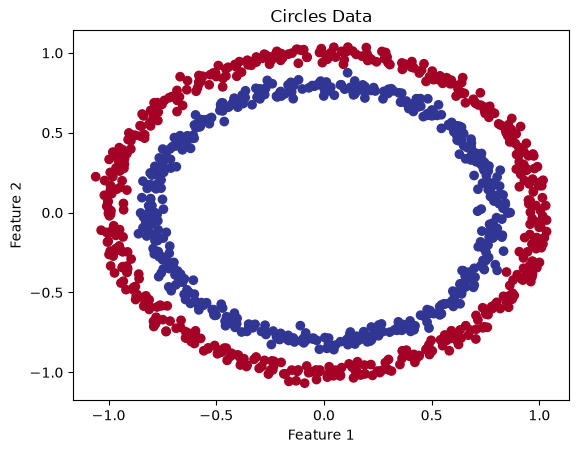

In [7]:
#visualize the data
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Circles Data")
plt.show()

**Note:** The day we are working with is also known as toy dataset. A dataset that is small enough to experiment but still sizeable enough to practice the fundamentals

### 1.1 check inp and out shape

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [10]:
#view the first 5 labels
X_sample=  X[0]
y_sample=  y[0]

print(f"Values for one sample of X:\n{X_sample} and the same for y:\n{y_sample}")
print(f"Shape of one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X:
[0.75424625 0.23148074] and the same for y:
1
Shape of one sample of X: (2,) and the same for y: ()


### 2. Turn data into tensors

In [11]:
#turn data into tensors
import torch
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [12]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [13]:
# split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Lets build a model to classify our blue and red dots
to do so we want to:
1. Set up device agnostic code so our code will run on an accelerator(gpu) if there is one
2. Construct a model(by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a traning and test loop

In [15]:
# import pytorch and nn
import torch
from torch import nn

# make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [16]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we have setup device agnostic code lets create a model that:
1. Subclasses 'nn.Module' (almost all models in Pytorch subclass 'nn.Module)
2. Create 2 'nn.Linear()' layers that are capable of handling the shapes of our data
3. Defube a forward() method that outlines the forward pass(or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target device

In [17]:
#1. Construct a model by subclassing nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=5) # takes in 2 features and outputs 5 features
        self.layer_2=nn.Linear(in_features=5, out_features=1) # takes in 5 features and outputs 1 feature( same shape as y)
    
    # define forward function to define how data moves through the model
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) #x->layer_1-->layer_2-->output

# Instantiate the model and send it to the target device
model_0=CircleModelV0().to(device)
model_0        

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
device

'cuda'

In [19]:
next(model_0.parameters()).device

device(type='cuda', index=0)